# 🌩️ Weather Anomaly Detection Pipeline
**ERA5 fetch → Windy fetch → Isolation Forest → store scores**

## 0. Config

In [17]:
import os, warnings
import numpy as np
import pandas as pd
import cdsapi
import xarray as xr
import requests
import psycopg2
from psycopg2.extras import execute_values
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

# ── Spatial / temporal scope ───────────────────────────────────────────────────
REGION = {
    "lat_min": 40.5,  "lat_max": 55.5,   # Kazakhstan bounding box
    "lon_min": 50.0,  "lon_max": 87.5,
}
GRID_POINTS = [                            # Windy point-forecast inference grid
    {"lat": 51.18, "lon": 71.45},          # Astana
    {"lat": 43.25, "lon": 76.95},          # Almaty
    {"lat": 42.30, "lon": 69.60},          # Shymkent
]
ERA5_START   = "2024-01-01"
ERA5_END     = "2025-12-31"
ERA5_OUTFILE = "era5_raw.nc"

# ── Windy ──────────────────────────────────────────────────────────────────────
WINDY_KEY   = os.getenv("WINDY_API_KEY", "YOUR_KEY_HERE")
WINDY_MODEL = "gfs"   # 'gfs' | 'iconEu' | 'arome'
OPEN_METEO_URL = "https://api.open-meteo.com/v1/forecast"

# ── TimescaleDB ────────────────────────────────────────────────────────────────
DB_CONFIG = {
    "host":     os.getenv("TSDB_HOST",     "localhost"),
    "port":     int(os.getenv("TSDB_PORT", "5432")),
    "dbname":   os.getenv("TSDB_DBNAME",   "weather_anomalies"),
    "user":     os.getenv("TSDB_USER",     "postgres"),
    "password": os.getenv("TSDB_PASSWORD", ""),
}

# ── Isolation Forest ──────────────────────────────────────────────────────────
IF_CONTAMINATION = 0.001   # expected anomaly fraction
IF_N_ESTIMATORS  = 200
MODEL_PATH       = "isolation_forest.joblib"
SCALER_PATH      = "scaler.joblib"

print("✅ Config loaded")

✅ Config loaded


## 1. ERA5 — Fetch Historical Data

In [2]:
import glob

# CDS API reads ~/.cdsapirc for credentials automatically
# File format:
#   url: https://cds.climate.copernicus.eu/api/v2
#   key: <UID>:<API-KEY>

c      = cdsapi.Client()
months = [f"{m:02d}" for m in range(1, 13)]
days   = [f"{d:02d}" for d in range(1, 32)]
times  = [f"{h:02d}:00" for h in range(0, 24, 3)]  # 3-hourly

# Fetch one file per year — avoids CDS 403 'request too large'
yearly_files = []
for year in range(int(ERA5_START[:4]), int(ERA5_END[:4]) + 1):
    outfile = f"era5_raw_{year}.nc"
    yearly_files.append(outfile)
    if os.path.exists(outfile):
        print(f"⏭️  {outfile} already exists, skipping")
        continue
    print(f"⬇️  Fetching ERA5 {year}...")
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
                "total_precipitation",
                "2m_temperature",
            ],
            "year":  str(year),
            "month": months,
            "day":   days,
            "time":  times,
            "area":  [REGION["lat_max"], REGION["lon_min"],
                      REGION["lat_min"], REGION["lon_max"]],
            "format": "netcdf",
        },
        outfile,
    )
    print(f"✅ Saved {outfile}")

ERA5_OUTFILE = yearly_files  # passed as list to xr.open_mfdataset in next cell
print(f"\n📦 Files ready: {yearly_files}")

⏭️  era5_raw_2024.nc already exists, skipping
⏭️  era5_raw_2025.nc already exists, skipping

📦 Files ready: ['era5_raw_2024.nc', 'era5_raw_2025.nc']


## 2. ERA5 — Preprocess into Feature DataFrame

In [3]:
import zipfile

extracted = []
for zf in ERA5_OUTFILE:
    out_dir = zf.replace(".nc", "_extracted")
    os.makedirs(out_dir, exist_ok=True)
    with zipfile.ZipFile(zf, "r") as z:
        z.extractall(out_dir)
        extracted += [os.path.join(out_dir, f) for f in z.namelist() if f.endswith(".nc")]

ds = xr.concat([xr.open_dataset(f, engine="netcdf4") for f in extracted], dim="time")
print(ds)

<xarray.Dataset> Size: 3GB
Dimensions:     (time: 4, valid_time: 5848, latitude: 61, longitude: 151)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 47kB 2024-01-01 ... 2025-12-31T21...
    expver      (time, valid_time) object 187kB '0001' '0001' ... '0001' '0001'
  * latitude    (latitude) float64 488B 55.5 55.25 55.0 ... 41.0 40.75 40.5
  * longitude   (longitude) float64 1kB 50.0 50.25 50.5 ... 87.0 87.25 87.5
    number      int64 8B 0
Dimensions without coordinates: time
Data variables:
    u10         (time, valid_time, latitude, longitude) float32 862MB 5.308 ....
    v10         (time, valid_time, latitude, longitude) float32 862MB -3.851 ...
    t2m         (time, valid_time, latitude, longitude) float32 862MB 263.4 ....
    tp          (time, valid_time, latitude, longitude) float32 862MB nan ......
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventi

In [4]:
def preprocess_era5(ds: xr.Dataset) -> pd.DataFrame:
    def get_var(name):
        for i in range(ds.dims["time"]):
            arr = ds.isel(time=i)[name].values
            if not np.isnan(arr).all():
                return ds.isel(time=i)[name]
        raise ValueError(f"all time slices are NaN for {name}")

    lat = ds["latitude"].values
    lon = ds["longitude"].values
    lat_g, lon_g = np.meshgrid(lat, lon, indexing="ij")
    lat_flat = lat_g.ravel()
    lon_flat = lon_g.ravel()

    u10 = get_var("u10")
    v10 = get_var("v10")
    t2m = get_var("t2m")
    tp  = get_var("tp")

    chunks = []
    prev_tp   = None
    prev_hour = None

    for i in range(len(ds["valid_time"])):
        wu   = u10.isel(valid_time=i).values.ravel()
        wv   = v10.isel(valid_time=i).values.ravel()
        tk   = t2m.isel(valid_time=i).values.ravel()
        tpi  = tp.isel(valid_time=i).values.ravel()
        hour = pd.Timestamp(ds["valid_time"].values[i]).hour

        reset = (prev_hour is not None) and (hour in (1, 12))

        if prev_tp is None or reset:
            precip_3h = tpi.copy()
        else:
            precip_3h = np.clip(tpi - prev_tp, 0, None)
        prev_tp   = tpi.copy()
        prev_hour = hour

        chunks.append(pd.DataFrame({
            "time":       ds["valid_time"].values[i],
            "lat":        lat_flat,
            "lon":        lon_flat,
            "wind_u":     wu,
            "wind_v":     wv,
            "wind_speed": np.sqrt(wu**2 + wv**2),
            "precip_3h":  precip_3h,
            "temp_k":     tk,
        }))

    return pd.concat(chunks, ignore_index=True)

era5_df = preprocess_era5(ds)
print(f"ERA5 rows: {len(era5_df):,}")
era5_df.head()

ERA5 rows: 53,865,928


,time,lat,lon,wind_u,wind_v,wind_speed,precip_3h,temp_k
0,2024-01-01,55.5,50.00,5.308380,-3.850906,6.558077,0.000045,263.362793
1,2024-01-01,55.5,50.25,5.378693,-3.411453,6.369328,0.000050,263.513184
2,2024-01-01,55.5,50.50,5.471466,-2.944656,6.213529,0.000051,263.708496
3,2024-01-01,55.5,50.75,5.586700,-2.440750,6.096596,0.000052,263.983887
4,2024-01-01,55.5,51.00,5.926544,-2.050125,6.271120,0.000057,264.308105


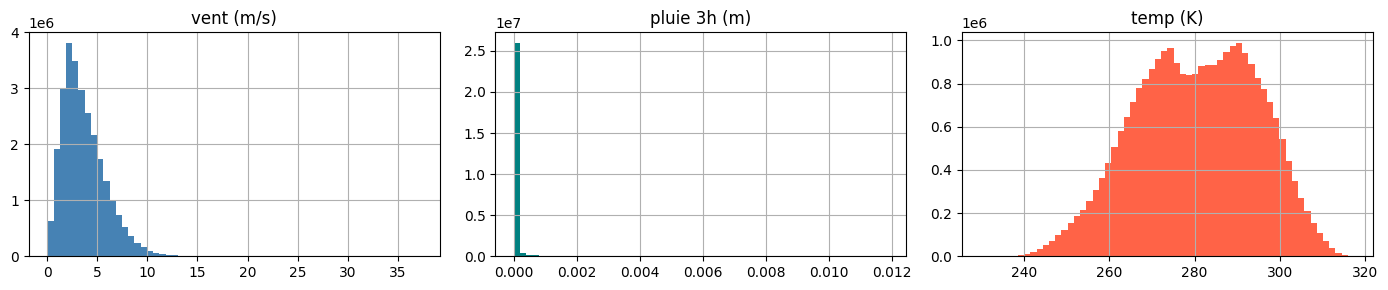

In [5]:
# Quick sanity check — distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
era5_df["wind_speed"].hist(bins=60, ax=axes[0], color="steelblue");  axes[0].set_title("vent (m/s)")
era5_df["precip_3h"].hist(bins=60, ax=axes[1], color="teal");        axes[1].set_title("pluie 3h (m)")
era5_df["temp_k"].hist(bins=60, ax=axes[2], color="tomato");         axes[2].set_title("temp (K)")
plt.tight_layout()
plt.show()

## 3. ERA5 — Insert into TimescaleDB

In [ ]:
def insert_era5(df: pd.DataFrame, batch_size: int = 2000):
    conn = psycopg2.connect(**DB_CONFIG)
    cur  = conn.cursor()

    sql = """
        INSERT INTO era5_observations (time, lat, lon, wind_u, wind_v, precip_3h, temp_k)
        VALUES %s
        ON CONFLICT (time, lat, lon) DO NOTHING
    """
    cols = ["time", "lat", "lon", "wind_u", "wind_v", "precip_3h", "temp_k"]
    for i in range(0, len(df), batch_size):
        batch = df.iloc[i:i+batch_size][cols].values.tolist()
        execute_values(cur, sql, batch)
        conn.commit()
        print(f"  inserted {min(i+batch_size, len(df))}/{len(df)}")

    cur.close()
    conn.close()
    print(f"✅ ERA5 insert done — {len(df):,} rows")

insert_era5(era5_df)

## 4. Windy — Live Point-Forecast Fetch

In [18]:
def fetch_open_meteo(lat: float, lon: float) -> pd.DataFrame:
    resp = requests.get(OPEN_METEO_URL, params={
        "latitude":        lat,
        "longitude":       lon,
        "hourly":          ["wind_speed_10m", "precipitation", "temperature_2m"],
        "wind_speed_unit": "ms",
        "temperature_unit":"celsius",
        "timeformat":      "unixtime",
        "timezone":        "UTC",
        "forecast_days":   16,
    }, timeout=15)
    resp.raise_for_status()
    d = resp.json()["hourly"]

    df = pd.DataFrame({
        "time":       pd.to_datetime(d["time"], unit="s", utc=True),
        "wind_speed": np.array(d["wind_speed_10m"], dtype=float),
        "precip_3h":  np.array(d["precipitation"],  dtype=float) / 1000,
        "temp_k":     np.array(d["temperature_2m"], dtype=float) + 273.15,
    }).set_index("time")

    # resample to 3h: wind/temp → mean, precip → sum (accumulate over 3h)
    df = pd.DataFrame({
        "wind_speed": df["wind_speed"].resample("3h").mean(),
        "precip_3h":  df["precip_3h"].resample("3h").sum(),
        "temp_k":     df["temp_k"].resample("3h").mean(),
    }).reset_index()

    df["lat"]    = lat
    df["lon"]    = lon
    df["wind_u"] = df["wind_speed"]
    df["wind_v"] = 0.0

    return df


windy_df = pd.concat(
    [fetch_open_meteo(p["lat"], p["lon"]) for p in GRID_POINTS],
    ignore_index=True
).dropna(subset=FEATURES)

print(f"✅ Open-Meteo rows fetched: {len(windy_df)}")
windy_df.head()

✅ Open-Meteo rows fetched: 384


,time,wind_speed,precip_3h,temp_k,lat,lon,wind_u,wind_v
0,2026-03-04 00:00:00+00:00,3.153333,0.0,264.716667,51.18,71.45,3.153333,0.0
1,2026-03-04 03:00:00+00:00,3.403333,0.0,264.383333,51.18,71.45,3.403333,0.0
2,2026-03-04 06:00:00+00:00,3.813333,0.0,267.783333,51.18,71.45,3.813333,0.0
3,2026-03-04 09:00:00+00:00,4.250000,0.0,269.983333,51.18,71.45,4.250000,0.0
4,2026-03-04 12:00:00+00:00,3.890000,0.0,268.583333,51.18,71.45,3.890000,0.0


In [20]:
def insert_windy(df: pd.DataFrame, config: dict):
    conn = psycopg2.connect(**config)
    cur  = conn.cursor()

    if "model" not in df.columns:
        df = df.copy()
        df["model"] = "open-meteo"

    records = [
        (row.time, row.lat, row.lon, row.model, row.wind_u, row.wind_v, row.precip_3h, row.temp_k)
        for row in df.itertuples()
    ]

    sql = """
        INSERT INTO windy_forecasts (time, lat, lon, model, wind_u, wind_v, precip_3h, temp_k)
        VALUES %s
        ON CONFLICT (time, lat, lon, model) DO UPDATE SET
            wind_u     = EXCLUDED.wind_u,
            wind_v     = EXCLUDED.wind_v,
            precip_3h  = EXCLUDED.precip_3h,
            temp_k     = EXCLUDED.temp_k,
            fetched_at = NOW()
    """
    execute_values(cur, sql, records)
    conn.commit()
    cur.close()
    conn.close()
    print(f"✅ Windy insert done — {len(records)} rows")

insert_windy(windy_df, DB_CONFIG)

✅ Windy insert done — 384 rows


## 5. Train Isolation Forest on ERA5

In [8]:
FEATURES = ["wind_speed", "precip_3h", "temp_k"]

X_train = era5_df[FEATURES].dropna().values

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

iso_forest = IsolationForest(
    n_estimators=IF_N_ESTIMATORS,
    contamination=IF_CONTAMINATION,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_scaled)

joblib.dump(iso_forest, MODEL_PATH)
joblib.dump(scaler,     SCALER_PATH)
print(f"✅ Model trained on {len(X_train):,} ERA5 samples")
print(f"   Saved → {MODEL_PATH}, {SCALER_PATH}")

✅ Model trained on 26,969,808 ERA5 samples
   Saved → isolation_forest.joblib, scaler.joblib


In [10]:
# Score threshold used by the model (decision_function == 0 boundary)
threshold = iso_forest.offset_
print(f"Decision threshold (offset_): {threshold:.4f}")

# In-sample anomaly rate sanity check
preds = iso_forest.predict(X_scaled)
anomaly_rate = (preds == -1).mean()
print(f"In-sample anomaly rate: {anomaly_rate:.2%}  (target: {IF_CONTAMINATION:.2%})")

Decision threshold (offset_): -0.7475
In-sample anomaly rate: 0.10%  (target: 0.10%)


## 6. Inference — Score Windy Forecasts

In [21]:
def run_inference(df: pd.DataFrame, source: str) -> pd.DataFrame:
    """
    Runs Isolation Forest on any DataFrame that has wind_speed, precip_3h, temp_k.
    Returns the input DataFrame with anomaly_score and is_anomaly columns appended.
    """
    model  = joblib.load(MODEL_PATH)
    sc     = joblib.load(SCALER_PATH)

    out = df.copy()
    valid = out[FEATURES].dropna()

    X      = sc.transform(valid.values)
    scores = model.decision_function(X)   # higher = more normal
    labels = model.predict(X)             # 1 = normal, -1 = anomaly

    out.loc[valid.index, "anomaly_score"] = scores
    out.loc[valid.index, "is_anomaly"]    = labels == -1
    out["source"]    = source
    out["threshold"] = model.offset_

    return out


windy_scored = run_inference(windy_df, source="windy")

n_anomalies = windy_scored["is_anomaly"].sum()
print(f"Windy anomalies detected: {n_anomalies} / {len(windy_scored)} ({n_anomalies/len(windy_scored):.1%})")
windy_scored[windy_scored["is_anomaly"]][["time","lat","lon","wind_speed","precip_3h","temp_k","anomaly_score"]].head(10)

Windy anomalies detected: 14 / 384 (3.6%)


,time,lat,lon,wind_speed,precip_3h,temp_k,anomaly_score
181,2026-03-10 15:00:00+00:00,43.25,76.95,0.940000,0.0032,277.216667,-0.014296
182,2026-03-10 18:00:00+00:00,43.25,76.95,2.033333,0.0028,274.116667,-0.008714
183,2026-03-10 21:00:00+00:00,43.25,76.95,2.413333,0.0036,274.316667,-0.010055
184,2026-03-11 00:00:00+00:00,43.25,76.95,1.723333,0.0031,273.283333,-0.011776
185,2026-03-11 03:00:00+00:00,43.25,76.95,4.323333,0.0022,271.483333,-0.004318
257,2026-03-04 03:00:00+00:00,42.30,69.60,4.900000,0.0073,280.550000,-0.002241
258,2026-03-04 06:00:00+00:00,42.30,69.60,4.980000,0.0065,278.716667,-0.006224
265,2026-03-05 03:00:00+00:00,42.30,69.60,0.780000,0.0035,278.516667,-0.014462
268,2026-03-05 12:00:00+00:00,42.30,69.60,1.713333,0.0048,278.150000,-0.010342
303,2026-03-09 21:00:00+00:00,42.30,69.60,3.353333,0.0037,277.683333,-0.002146


## 7. Store Anomaly Scores

In [22]:
def insert_scores(df: pd.DataFrame, config: dict):
    conn = psycopg2.connect(**config)
    cur  = conn.cursor()

    scored = df.dropna(subset=["anomaly_score"])
    records = [
        (
            row.time, row.lat, row.lon, row.source,
            row.anomaly_score, bool(row.is_anomaly), row.threshold,
            row.wind_speed, row.precip_3h, row.temp_k,
        )
        for row in scored.itertuples()
    ]

    sql = """
        INSERT INTO anomaly_scores
            (time, lat, lon, source, anomaly_score, is_anomaly, threshold, wind_speed, precip_3h, temp_k)
        VALUES %s
        ON CONFLICT (time, lat, lon, source) DO UPDATE SET
            anomaly_score = EXCLUDED.anomaly_score,
            is_anomaly    = EXCLUDED.is_anomaly,
            threshold     = EXCLUDED.threshold
    """
    execute_values(cur, sql, records)
    conn.commit()
    cur.close()
    conn.close()
    print(f"✅ Scores stored — {len(records)} rows")


insert_scores(windy_scored, DB_CONFIG)

✅ Scores stored — 384 rows


## 8. Quick Visualisation

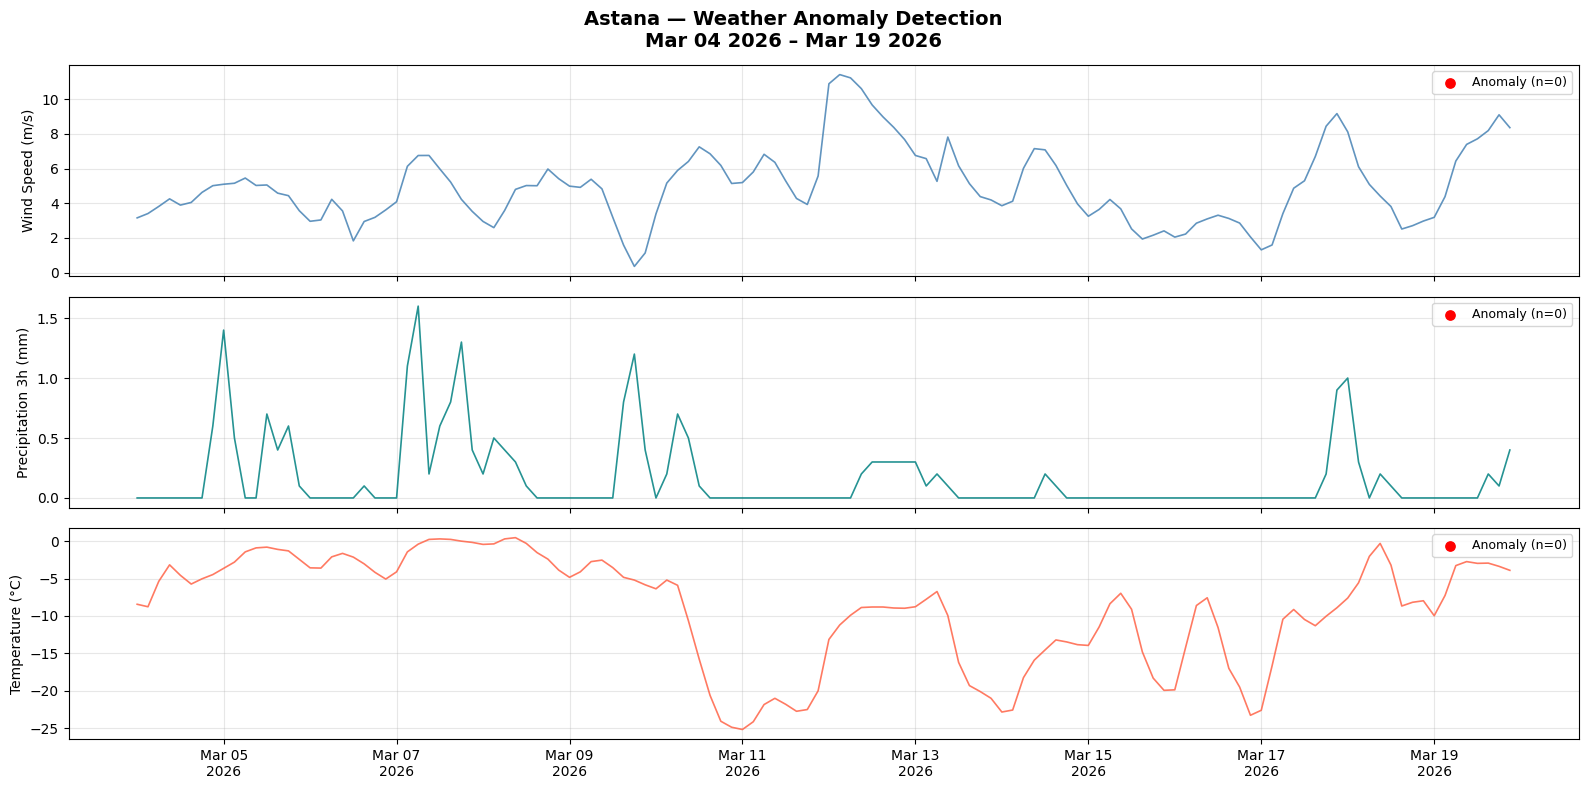

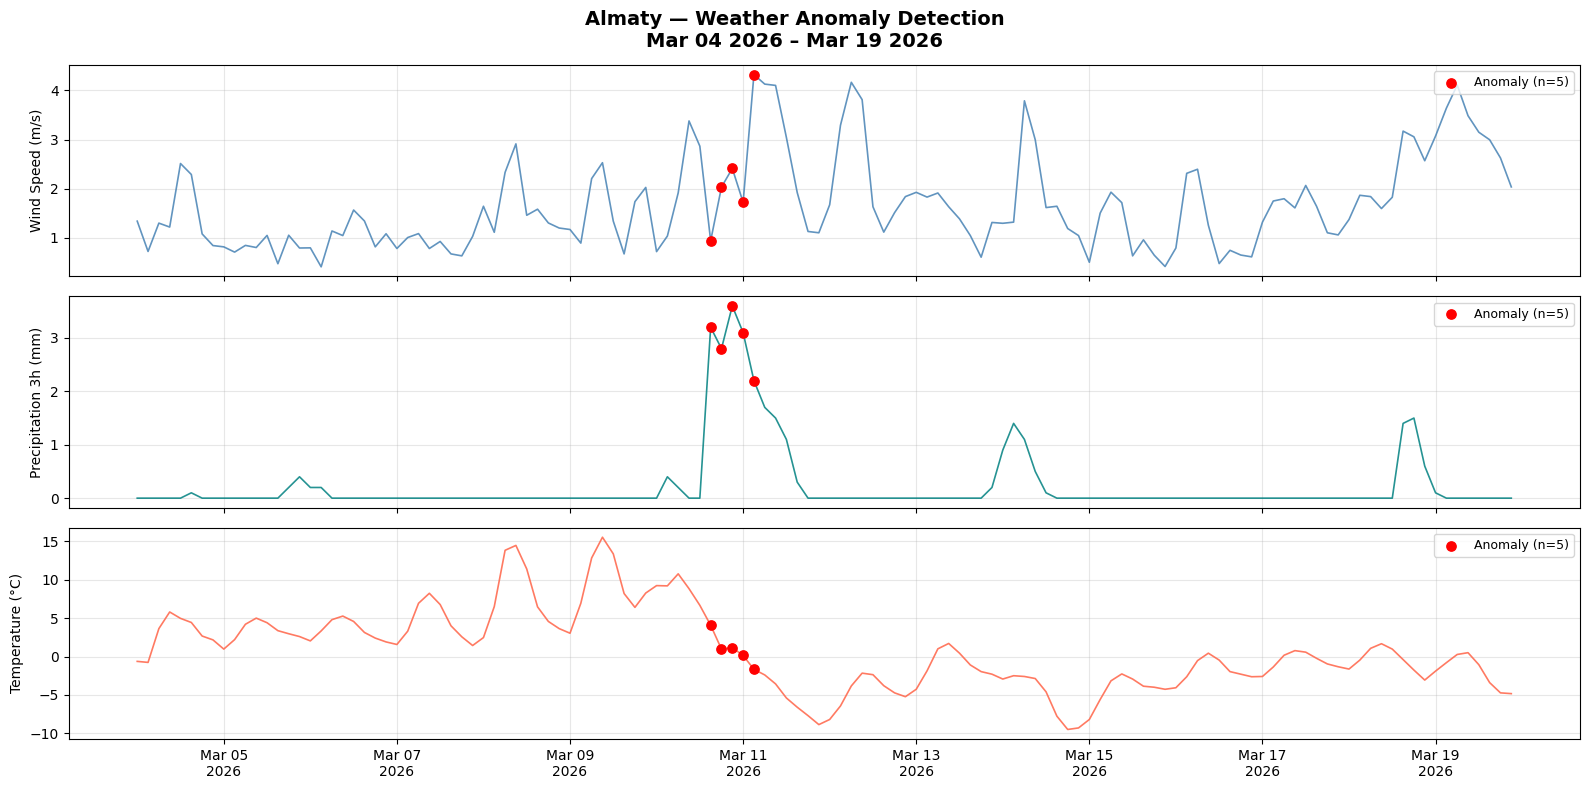

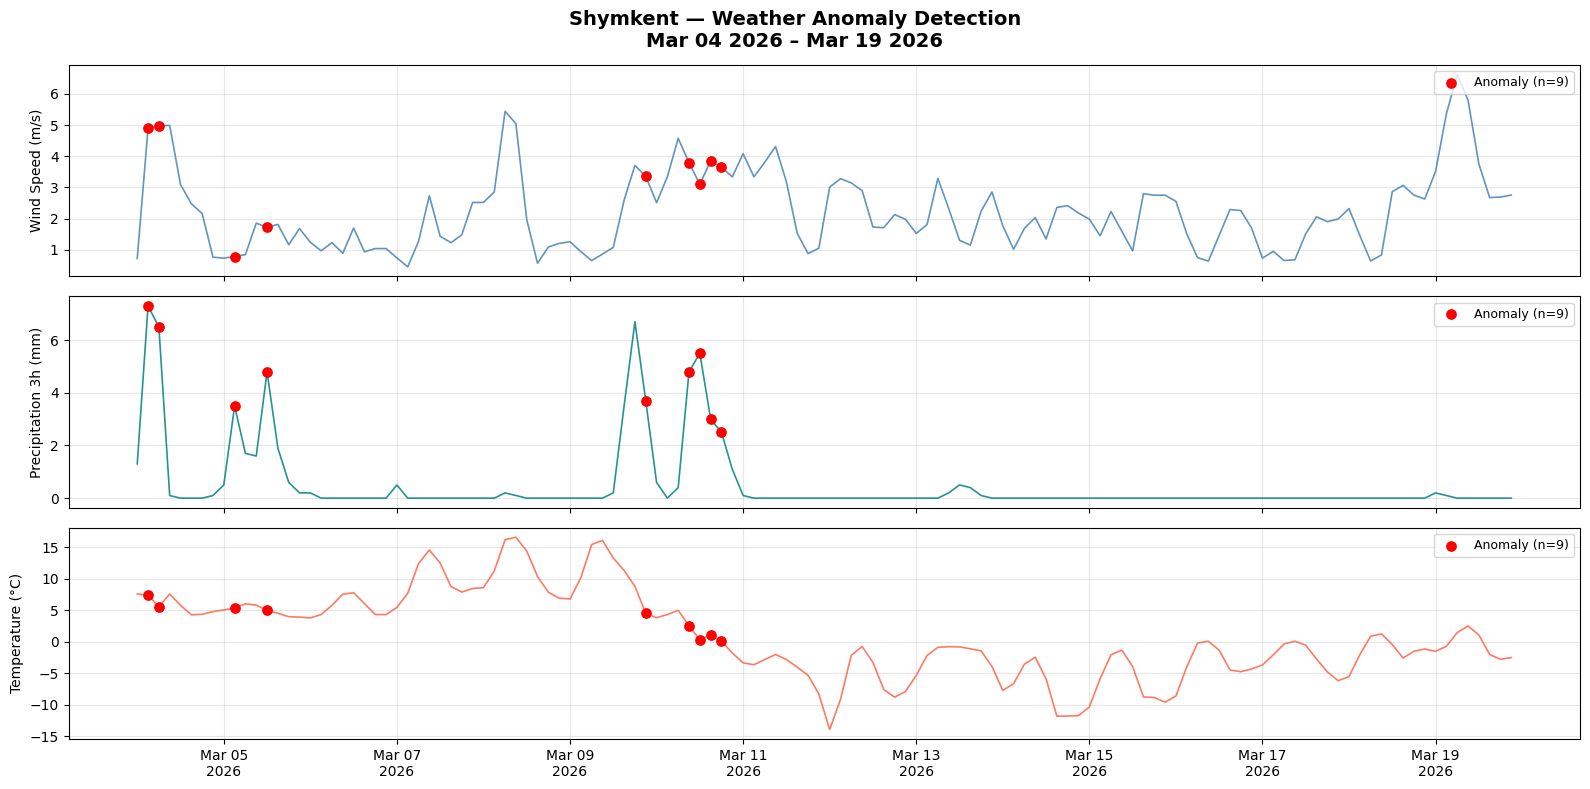

In [23]:
CITY_NAMES = {
    (51.18, 71.45): "Astana",
    (43.25, 76.95): "Almaty",
    (42.30, 69.60): "Shymkent",
}

for point in GRID_POINTS:
    sub = windy_scored[
        (windy_scored["lat"] == point["lat"]) &
        (windy_scored["lon"] == point["lon"])
    ].copy().sort_values("time")
    if sub.empty:
        continue

    city = CITY_NAMES.get((point["lat"], point["lon"]), f"lat={point['lat']} lon={point['lon']}")
    date_range = f"{sub['time'].min().strftime('%b %d %Y')} – {sub['time'].max().strftime('%b %d %Y')}"

    fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(f"{city} — Weather Anomaly Detection\n{date_range}", fontsize=14, fontweight="bold")

    var_cfg = [
        ("wind_speed", "Wind Speed (m/s)",         "steelblue",  None),
        ("precip_3h",  "Precipitation 3h (mm)",     "teal",       1000),  # m → mm
        ("temp_k",     "Temperature (°C)",           "tomato",     None),  # K → °C
    ]

    for ax, (col, label, color, scale) in zip(axes, var_cfg):
        y = sub[col].copy()
        if scale:
            y = y * scale
        if col == "temp_k":
            y = y - 273.15

        ax.plot(sub["time"], y, color=color, lw=1.2, alpha=0.85)

        anomalies = sub[sub["is_anomaly"] == True]
        ya = anomalies[col].copy()
        if scale:
            ya = ya * scale
        if col == "temp_k":
            ya = ya - 273.15

        ax.scatter(anomalies["time"], ya, color="red", zorder=5, s=45,
                   label=f"Anomaly (n={len(anomalies)})")
        ax.set_ylabel(label, fontsize=10)
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(True, alpha=0.3)

        # year markers
        for year in sub["time"].dt.year.unique():
            yr_start = pd.Timestamp(f"{year}-01-01", tz="UTC")
            if sub["time"].min() <= yr_start <= sub["time"].max():
                ax.axvline(yr_start, color="gray", lw=1, linestyle="--", alpha=0.6)
                ax.text(yr_start, ax.get_ylim()[1], str(year),
                        fontsize=8, color="gray", ha="left", va="top")

    axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%Y"))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()